In [2]:
import os
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [3]:
DATASET_DIR = "../dataset"

IMAGE_DIR = os.path.join(DATASET_DIR, "images")
MASK_DIR = os.path.join(DATASET_DIR, "masks")

CSV_PATH = os.path.join(DATASET_DIR, "GroundTruth.csv")

In [4]:
df = pd.read_csv(CSV_PATH)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (10015, 8)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB


In [6]:
df.isnull().sum()

image    0
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
dtype: int64

In [7]:
print(df.columns.tolist())

['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [8]:
classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

df['label'] = df[classes].idxmax(axis=1)

df[['image', 'label']].head()

,image,label
0,ISIC_0024306,NV
1,ISIC_0024307,NV
2,ISIC_0024308,NV
3,ISIC_0024309,NV
4,ISIC_0024310,MEL


In [9]:
class_counts = df['label'].value_counts()

print(class_counts)

label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


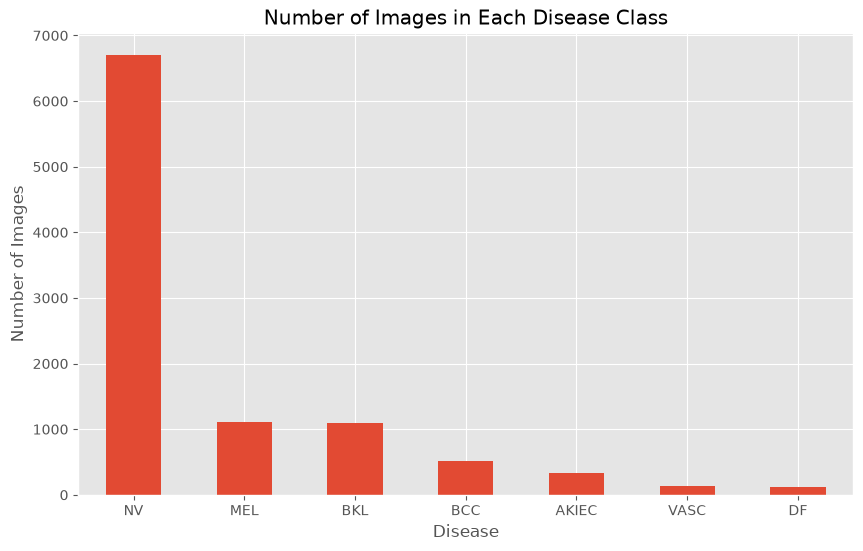

In [10]:
plt.figure(figsize=(10,6))

class_counts.plot(kind='bar')

plt.title("Number of Images in Each Disease Class")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.show()

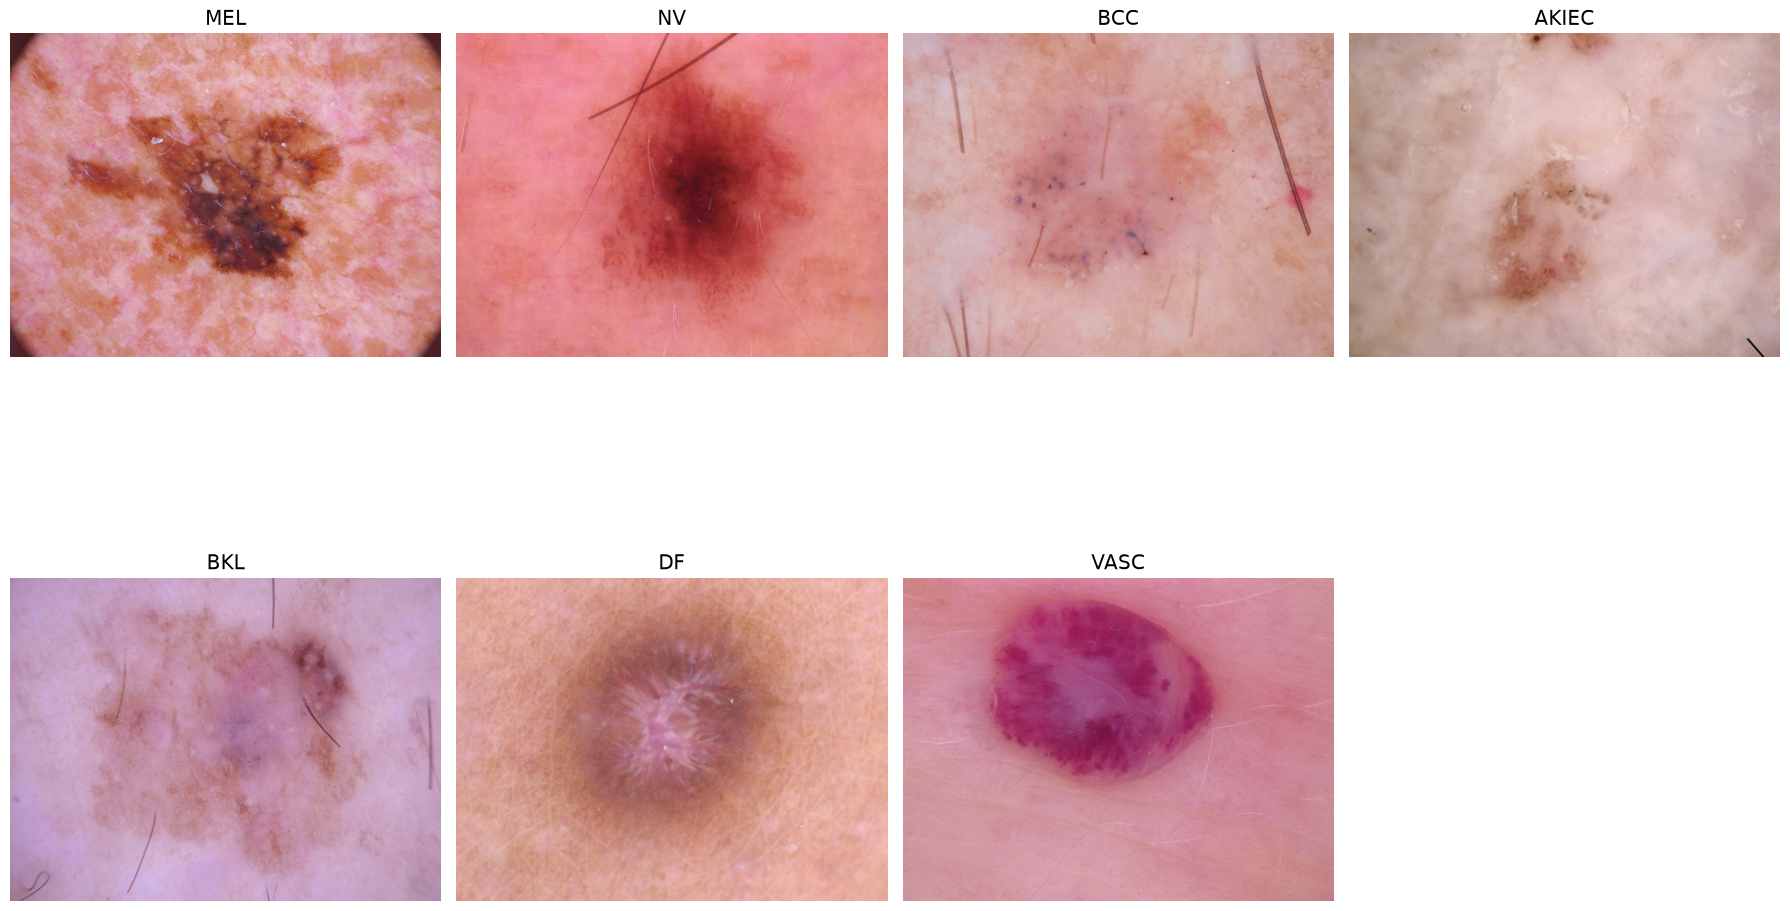

In [11]:
classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

plt.figure(figsize=(18, 12))

for i, disease in enumerate(classes):
    
    image_name = df[df['label'] == disease].iloc[0]['image']

    image_path = os.path.join(IMAGE_DIR, image_name + ".jpg")

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
sample_image = cv2.imread(os.path.join(IMAGE_DIR, df.iloc[0]['image'] + ".jpg"))

print("Image Shape:", sample_image.shape)

Image Shape: (450, 600, 3)


In [13]:
missing_images = []

for image_name in df['image']:
    image_path = os.path.join(IMAGE_DIR, image_name + ".jpg")

    if not os.path.exists(image_path):
        missing_images.append(image_name)

print("Missing Images:", len(missing_images))

Missing Images: 0


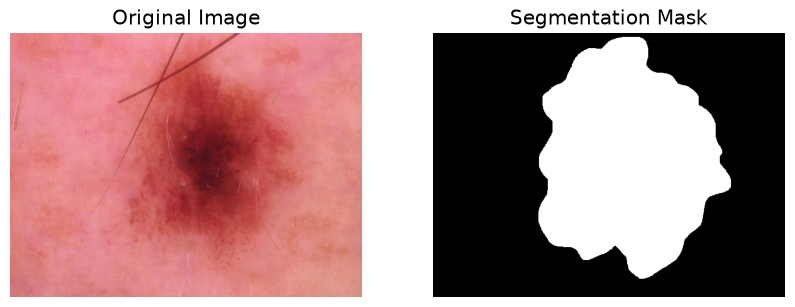

In [14]:
image_name = df.iloc[0]['image']

image_path = os.path.join(IMAGE_DIR, image_name + ".jpg")
mask_path = os.path.join(MASK_DIR, image_name + "_segmentation.png")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [15]:
import cv2
import numpy as np

In [16]:
IMAGE_SIZE = (224, 224)

In [17]:
def preprocess_image(image_path):
    """
    Reads and preprocesses an image.
    """

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, IMAGE_SIZE)

    image = image.astype(np.float32) / 255.0

    return image

In [18]:
import sys
sys.path.append("..")

from src.preprocessing import preprocess_image

In [19]:
sample_path = os.path.join(
    IMAGE_DIR,
    df.iloc[0]["image"] + ".jpg"
)

processed_image = preprocess_image(sample_path)

print(processed_image.shape)
print(processed_image.min(), processed_image.max())



(224, 224, 3)
0.0627451 0.96862745


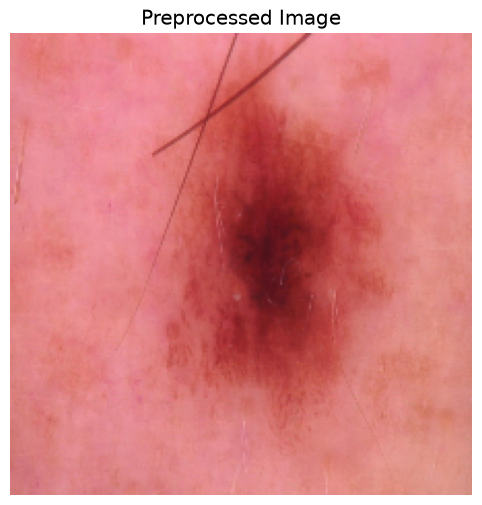

In [20]:
plt.figure(figsize=(6,6))
plt.imshow(processed_image)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()